社内の製品の受注予測を行う
データは、社内ＤＢから取得しsample_data.csvに保存する

In [17]:
# 必要なライブラリのimport
import pandas as pd
import numpy as np

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_predict

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()

In [18]:
# CSVファイルのデータを読み込む
csv_data = pd.read_csv('sample_data.csv')

# 先頭5件を表示
csv_data.head()


,日付,数量
0,15-06-05,64
1,15-06-08,63
2,15-06-09,68
3,15-06-10,71
4,15-06-11,109


In [19]:
# ARIMAを使用する為にインデックスを付けたデータに変換する
# 数量列のみでSeries型のデータを作る
data = csv_data["数量"]

# 日付列をPeriodIndex型に変換してdataのインデックスに設定する
dates = pd.to_datetime(csv_data["日付"], format="%y-%m-%d")
data_index = pd.PeriodIndex(dates, freq='D')

# Series 作成
data = pd.Series(csv_data["数量"].values, index=data_index)

# dataの先頭5行を表示
data.head()

日付
2015-06-05     64
2015-06-08     63
2015-06-09     68
2015-06-10     71
2015-06-11    109
Freq: D, dtype: int64

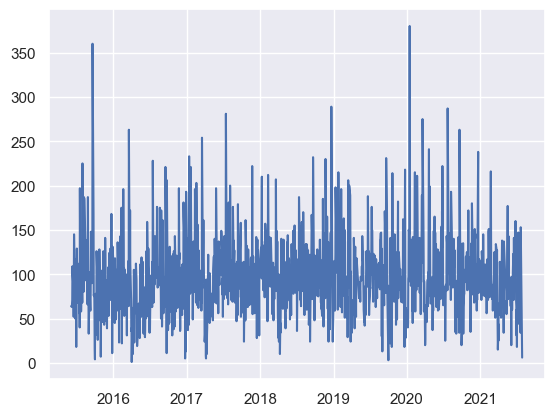

In [20]:
# データをグラフで確認
plt.plot(data.index.to_timestamp(), data.values)

In [21]:
# my_pmdarimaを活用し、時系列予測する
from my_pmdarima import auto_arima

# 最適なARIMAのパラメータをauto_arimaで調べる
arima_model_fit = auto_arima(data, seasonal=False, trace=True)

START  (2, 1, 2)                AIC= 15288.351
  (1, 1, 1)                AIC= 15314.684 Δ= 26.333  ( 0.12s)
  (1, 1, 2)                AIC= 15286.878 Δ=-1.472  ( 0.26s)
  (0, 1, 1)                AIC= 15365.636 Δ= 78.757  ( 0.06s)
  (0, 1, 2)                AIC= 15315.005 Δ= 28.126  ( 0.09s)
  (0, 1, 3)                AIC= 15290.631 Δ= 3.753  ( 0.20s)
  (1, 1, 3)                AIC= 15278.871 Δ=-8.008  ( 0.47s)
  (0, 1, 4)                AIC= 15277.178 Δ=-1.692  ( 0.32s)
  (0, 1, 5)                AIC= 15263.144 Δ=-14.034  ( 0.37s)
  (1, 1, 4)                AIC= 15269.749 Δ= 6.605  ( 0.53s)
  (1, 1, 5)                AIC= 15256.127 Δ=-7.017  ( 0.69s)
  (2, 1, 4)                AIC= 15274.084 Δ= 17.957  ( 0.66s)
  (2, 1, 5)                AIC= 15245.940 Δ=-10.188  ( 0.78s)
  (3, 1, 4)                AIC= 15246.114 Δ= 0.174  ( 0.86s)
  (3, 1, 5)                AIC= 15256.913 Δ= 10.973  ( 0.82s)

==> BEST  ARIMA(2, 1, 5)   AIC= 15245.940


Text(0.5, 1.0, '受注予測')

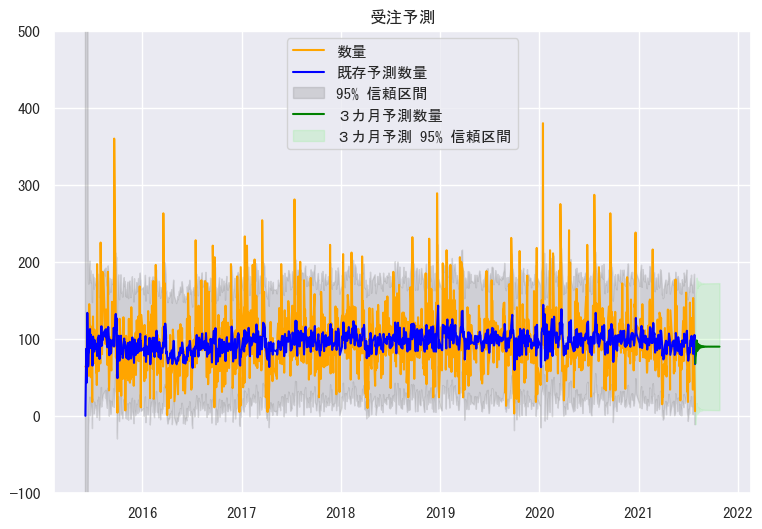

In [ ]:
# 最適なパラメータで予測し、グラフに表示する
# フォントの設定
plt.rcParams['font.family'] = 'MS Gothic' 

# 最適化ARIMAモデルによる回帰と予測の結果を描画
fig, ax = plt.subplots(figsize=(9,6))
ax.set_ylim(-100, 500)
ax.plot(data.index.to_timestamp(), data.values, label="数量", color="orange")

# 予測の実行
fit_predictions = arima_model_fit.get_prediction(start=data.index[0], end=data.index[-1])
fit_predicted_mean = fit_predictions.predicted_mean
fit_confidence_intervals = fit_predictions.conf_int()

# 予測値をプロット
ax.plot(fit_predicted_mean.index.to_timestamp(), fit_predicted_mean, label='既存予測数量', color='blue')
# 信頼区間をプロット
ax.fill_between(fit_confidence_intervals.index.to_timestamp(),
                fit_confidence_intervals.iloc[:, 0],
                fit_confidence_intervals.iloc[:, 1], color='gray', alpha=0.25, label='95% 信頼区間')

# 予測終了は３か月後
predict_end_period = 90  # 未来90日
predictions = arima_model_fit.get_forecast(steps=predict_end_period)

predicted_mean = predictions.predicted_mean
confidence_intervals = predictions.conf_int()

# 元データ末尾の日付
last_date = data.index[-1]

# 未来用に新しいPeriodIndexを作る
future_index = pd.period_range(start=last_date+1, periods=predict_end_period, freq='D')

# インデックスを上書き
predicted_mean.index = future_index
confidence_intervals.index = future_index

# 予測値をプロット
ax.plot(predicted_mean.index.to_timestamp(), predicted_mean, label='３カ月予測数量', color='green')
# 信頼区間をプロット
ax.fill_between(confidence_intervals.index.to_timestamp(),
                confidence_intervals.iloc[:, 0],
                confidence_intervals.iloc[:, 1], color='lightgreen', alpha=0.25, label='３カ月予測 95% 信頼区間')

ax.legend()
plt.title(f"受注予測")